## Joint Mapping

This project utilizes the FreiHAND dataset to train a Convolutional Neural Network (CNN) for 2D hand joint estimation in complex real-world hand poses. The model is trained to predict the locations of 21 hand joints from RGB images by generating heatmaps and estimating joint coordinates.

**How to run**

1. Download and place the FreiHAND dataset in a `freihand` folder (see file structure below)
2. Ensure the necessary dependencies are installed
>- pip install torch torchvision numpy pillow matplotlib tqdm
3. Run cells in order
>- Imports, Load Data/Preprocessing, Models, Training/Testing, Results

**Dataset:** FreiHAND Dataset

- Zimmermann, C., Ceylan, D., Yang, J., Russell, B., Argus, M., & Brox, T. (2019). *FreiHAND: A Dataset for Markerless Capture of Hand Pose and Shape from Single RGB Images*. IEEE International Conference on Computer Vision (ICCV). Dataset: <br>
https://lmb.informatik.uni-freiburg.de/resources/datasets/FreihandDataset.en.html

**Folder structure**
```Models/
├── freihand/
│   ├── rgb/
│   │   ├── 00000000.jpg
│   │   ├── 00000001.jpg
│   │   ├── ...
│   ├── training_K.json
│   ├── training_scale.json
│   └── training_xyz.json
└── JointMapping.ipynb

#### Imports

In [1]:
import os
import json
import random

import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from torchvision import transforms
from torch.utils.data import Subset
from torch.utils.data import Dataset, DataLoader

#### Load Data / Preprocessing

In [2]:
# Project 3D hand joints into 2D image coordinates
def projection(xyz, k):
    # xyz: 3D joint coordinates
    # k: camera intrinsic matrix
    xyz = np.array(xyz)
    k = np.array(k)

    x = xyz[:, 0]
    y = xyz[:, 1]
    z = xyz[:, 2]

    u = (k[0, 0] * x / z) + k[0, 2]
    v = (k[1, 1] * y / z) + k[1, 2]

    return np.stack([u, v], axis=1)

In [ ]:
class FreiHandDataset(Dataset):
    def __init__(self, root_dir, transform=None, augment=False):
        # File paths
        self.root_dir = root_dir
        self.rgb_dir = os.path.join(root_dir, "rgb")

        # Load annotations
        with open(os.path.join(root_dir, "training_xyz.json")) as f:
            self.xyz = json.load(f)
        with open(os.path.join(root_dir, "training_K.json")) as f:
            self.k = json.load(f)

        # Store samples and transforms
        self.images = sorted(os.listdir(self.rgb_dir))
        self.num_samples = len(self.xyz)
        self.transform = transform
        self.augment = augment

    def __len__(self):
        return len(self.images)

    def _augment(self, image, uv):
        width, height = image.size

        # Generate random transform
        scale = random.uniform(0.85, 1.15)
        angle = random.uniform(-30, 30)
        translate_x = random.uniform(-0.05, 0.05) * width
        translate_y = random.uniform(-0.05, 0.05) * height

        # Apply image transform
        image = TF.affine(image, angle=angle, translate=(translate_x, translate_y), scale=scale, shear=0.0, interpolation=transforms.InterpolationMode.BILINEAR)

        # Transform joint coordinates
        uv = uv.copy()
        angle_rad = np.deg2rad(angle)
        cos_a, sin_a = np.cos(angle_rad), np.sin(angle_rad)
        centered = uv - 0.5
        rotated = np.stack([centered[:, 0] * cos_a - centered[:, 1] * sin_a, centered[:, 0] * sin_a + centered[:, 1] * cos_a], axis=1)

        # Apply scaling and translation
        uv = rotated + 0.5
        uv[:, 0] = (uv[:, 0] - 0.5) * scale + 0.5 + translate_x / width
        uv[:, 1] = (uv[:, 1] - 0.5) * scale + 0.5 + translate_y / height
        uv = np.clip(uv, 0.0, 1.0)

        return image, uv

    def __getitem__(self, i):
        # Load input image
        image_name = self.images[i]
        image = Image.open(os.path.join(self.rgb_dir, image_name)).convert("RGB")

        # Project 3D joints
        pose_id = i % self.num_samples
        uv = projection(self.xyz[pose_id], self.k[pose_id]) / 224.0

        # Apply augmentation
        if self.augment:
            image, uv = self._augment(image, uv)
        if self.transform:
            image = self.transform(image)

        return {"image": image, "uv": torch.tensor(uv, dtype=torch.float32)}

In [ ]:
# Define image transforms
img_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_full = FreiHandDataset("freihand", transform=img_transforms, augment=True)
val_full = FreiHandDataset("freihand", transform=img_transforms, augment=False)

# Dataset stats
num_samples = train_full.num_samples
num_variants = len(train_full) // num_samples

# Shuffle pose indices
np.random.seed(42)
pose_ids = np.arange(num_samples)
np.random.shuffle(pose_ids)

# Manually split train and validation
split = int(0.9 * num_samples)
train_pose_ids = set(pose_ids[:split])
val_pose_ids = set(pose_ids[split:])

# Create dataset indices
train_indices = [i for i in range(len(train_full)) if i % num_samples in train_pose_ids]
val_indices = [i for i in range(len(val_full)) if i % num_samples in val_pose_ids]

# Create dataset subsets
train_dataset = Subset(train_full, train_indices)
val_dataset = Subset(val_full, val_indices)

print(f"Train (all variants): {len(train_dataset)}, Val (fixed): {len(val_dataset)}")

Train (all variants): 117216, Val (fixed): 13024


In [ ]:
def sample_pose_indices(pose_id_set, num_samples, num_variants):
    # Generate random pose variants
    return [random.randint(0, num_variants - 1) * num_samples + pose_id for pose_id in pose_id_set]

# Create validation loader
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

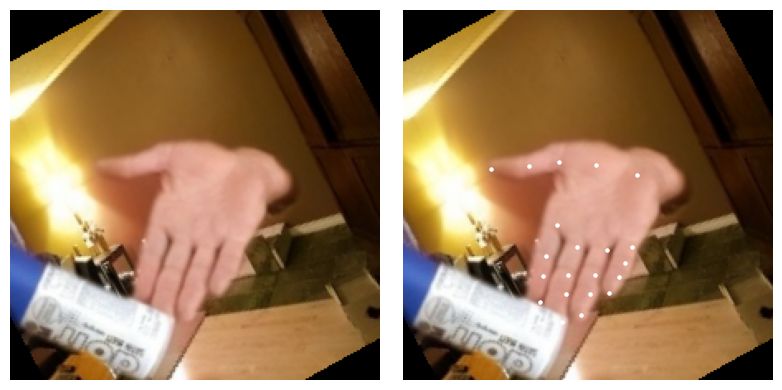

In [ ]:
# Get random sample and convert to (H, W, C)
idx = random.randint(0, len(train_dataset) - 1)
sample = train_dataset[idx]
image = sample["image"].permute(1, 2, 0)

# De-normalize image values
image = image * 0.5 + 0.5
image = image.clamp(0, 1)

# De-normalize uv coordinates
uv = sample["uv"] * 224

# Plot original image
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(image)
ax[0].axis("off")

# Plot image with joints
ax[1].imshow(image)
ax[1].scatter(uv[:, 0], uv[:, 1], c="w", s=5)
ax[1].axis("off")

plt.tight_layout()
plt.show()

#### Model

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride):
        super().__init__()

        # Main convolution path
        self.main = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, stride, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_channels)
        )

        # Shortcut connection path
        self.shortcut = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 1, stride, bias=False),
            nn.BatchNorm2d(out_channels)
        )

    def forward(self, x):
        # Add residual connection
        return F.relu(self.main(x) + self.shortcut(x))

In [ ]:
class JointMapping(nn.Module):
    def __init__(self, joints):
        super().__init__()
        # Store joint count
        self.joints = joints

        # Feature extractor
        self.conv1 = nn.Conv2d(3, 64, 7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(3, stride=2, padding=1)
        self.layer1 = ResidualBlock(64, 64, stride=1)
        self.layer2 = ResidualBlock(64, 128, stride=2)
        self.layer3 = ResidualBlock(128, 256, stride=2)
        self.layer4 = ResidualBlock(256, 256, stride=1)

        # Heatmap decoder
        self.heatmap_head = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, joints, kernel_size=1)
        )

        # Create coordinate grid
        size = 56
        cell_y, cell_x = torch.meshgrid((torch.arange(size).float() + 0.5) / size, (torch.arange(size).float() + 0.5) / size, indexing="ij")
        self.register_buffer("grid_x", cell_x.reshape(1, 1, -1))
        self.register_buffer("grid_y", cell_y.reshape(1, 1, -1))

    def soft_argmax(self, heatmaps):
        # Flatten heatmap probabilities
        batch, joints, height, width = heatmaps.shape
        prob = F.softmax(heatmaps.view(batch, joints, -1), dim=-1)

        # Compute weighted coordinates
        x = torch.sum(prob * self.grid_x, dim=-1)
        y = torch.sum(prob * self.grid_y, dim=-1)

        return torch.stack([x, y], dim=-1)

    def forward(self, x):
        # Extract image features
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        # Predict joint coordinates
        heatmaps = self.heatmap_head(x)
        coords = self.soft_argmax(heatmaps)

        return coords, heatmaps

In [8]:
# Check MPS support and use Apple GPU if available
print(torch.backends.mps.is_available())
print(torch.backends.mps.is_built())

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

True
True


In [ ]:
# Initialize model
model = JointMapping(joints=21).to(device)

print(model)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

JointMapping(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): ResidualBlock(
    (main): Sequential(
      (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (shortcut): Sequential(
      (0): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
  )
  (layer2): ResidualBlock(
    

In [ ]:
# Define hand skeleton bones (bone length consistency)
bones = [(0,1),  (1,2),   (2,3),   (3,4),
         (0,5),  (5,6),   (6,7),   (7,8),
         (0,9),  (9,10),  (10,11), (11,12),
         (0,13), (13,14), (14,15), (15,16),
         (0,17), (17,18), (18,19), (19,20)]

# Define finger joints (finger alignment consistency)
fingers = [[1, 2, 3], [5, 6, 7], [9, 10, 11], [13, 14, 15], [17, 18, 19]]

# Create heatmap grid
heatmap_size = 56
cell_y, cell_x = torch.meshgrid(torch.arange(heatmap_size, device=device).float(),torch.arange(heatmap_size, device=device).float(), indexing="ij")
cell_x = cell_x.unsqueeze(0).unsqueeze(0)
cell_y = cell_y.unsqueeze(0).unsqueeze(0)


def make_gaussian_targets(uv, heatmap_size=56, sigma=3.0):
    batch, joints, _ = uv.shape

    # Convert coordinates to heatmap scale
    target_x = (uv[:, :, 0] * heatmap_size).view(batch, joints, 1, 1)
    target_y = (uv[:, :, 1] * heatmap_size).view(batch, joints, 1, 1)

    # Generate gaussian heatmaps
    gaussian = torch.exp(-((cell_x - target_x) ** 2 + (cell_y - target_y) ** 2) / (2 * sigma ** 2))

    return gaussian


def heatmap_supervision_loss(pred_heatmaps, uv, sigma=3.0):
    # Make target heatmaps
    target = make_gaussian_targets(uv, heatmap_size=pred_heatmaps.shape[-1], sigma=sigma)

    # Convert predictions to probabilities
    pred_prob = F.softmax(pred_heatmaps.view(pred_heatmaps.shape[0], pred_heatmaps.shape[1], -1), dim=-1)
    pred_prob = pred_prob.view_as(pred_heatmaps)

    # Normalize target heatmaps
    target_norm = target / (target.sum(dim=(-1, -2), keepdim=True) + 1e-6)

    return F.mse_loss(pred_prob, target_norm)

def bone_loss(pred, gt):
    loss = 0.0
    
    # Compare bone lengths
    for a, b in bones:
        pred_len = torch.norm(pred[:, a] - pred[:, b], dim=1)
        gt_len = torch.norm(gt[:, a] - gt[:, b], dim=1)
        loss += torch.mean((pred_len - gt_len) ** 2)

    return loss / len(bones)


def finger_consistency_loss(pred):
    loss = 0.0
    
    # Measure finger alignment
    for base, mid, tip in fingers:
        v = pred[:, tip] - pred[:, base]
        u = pred[:, mid] - pred[:, base]

        # Project joint onto finger direction
        factor = torch.sum(u * v, dim=-1) / (torch.sum(v * v, dim=-1) + 1e-6)
        projection = pred[:, base] + factor.unsqueeze(-1) * v
        drift = torch.norm(pred[:, mid] - projection, dim=-1)
        loss += torch.mean(drift)

    return loss / len(fingers)

def compute_loss(pred, gt, heatmaps):
    # Compute coordinate losses
    coord_loss = F.smooth_l1_loss(pred, gt)
    bone_loss = bone_loss(pred, gt)
    consistency_loss = finger_consistency_loss(pred)
    heatmap_loss = heatmap_supervision_loss(heatmaps, gt, sigma=3.0)

    return coord_loss + 0.2 * bone_loss + 0.2 * consistency_loss + 0.5 * heatmap_loss

#### Training/Testing

In [ ]:
def train(model, loader, optimizer, device):
    # Set model to training mode
    model.train()

    # Track metrics
    total_loss_val = 0.0
    total_pixel_error = 0.0

    # Progress bar
    train_bar = tqdm(loader, desc="Training", leave=False)

    for batch in train_bar:
        # Load data to device
        images = batch["image"].to(device)
        uv = batch["uv"].to(device)

        # Forward pass
        preds, heatmaps = model(images)

        # Compute loss 
        loss = compute_loss(preds, uv, heatmaps)

        # Backpropagation step
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Metrics
        total_loss_val += loss.item()
        pixel_error = torch.mean(torch.norm((preds - uv) * 224, dim=-1))
        total_pixel_error += pixel_error.item()

        # Update progress bar
        train_bar.set_postfix(loss=loss.item(), pixel_error=pixel_error.item())

    return total_loss_val / len(loader), total_pixel_error / len(loader)

In [12]:
def test(model, loader, device):
    # Set model to evaluation mode
    model.eval()

    # Track metrics
    total_loss_val = 0.0
    total_pixel_error = 0.0

    # Progress bar
    test_bar = tqdm(loader, desc="Testing", leave=False)

    with torch.no_grad():
        for batch in test_bar:

            # Load data to device
            images = batch["image"].to(device)
            uv = batch["uv"].to(device)

            # Forward pass
            preds, heatmaps = model(images)

            # Compute loss
            loss = compute_loss(preds, uv, heatmaps)

            # Metrics
            total_loss_val += loss.item()
            pixel_error = torch.mean(torch.norm((preds - uv) * 224, dim=-1))
            total_pixel_error += pixel_error.item()

            # Update progress bar
            test_bar.set_postfix(loss=loss.item(), px_err=pixel_error.item())

    return total_loss_val / len(loader), total_pixel_error / len(loader)

In [ ]:
# Metrics storage
train_losses, val_losses = [], []
train_errors, val_errors = [], []

# Setup training variables
start_epoch = 0
epochs = 50
checkpoint_path = "checkpoint_joint_mapping.pth"
best_model_path = "best_model_joint_mapping.pth"
best_val_error = float("inf")

# Load checkpoint if available
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])

    start_epoch = checkpoint["epoch"] + 1
    best_val_error = checkpoint["best_val_error"]

    train_losses = checkpoint["train_losses"]
    val_losses = checkpoint["val_losses"]
    train_errors = checkpoint["train_errors"]
    val_errors = checkpoint["val_errors"]

for epoch in range(start_epoch, epochs):
    # Generate training samples
    epoch_train_indices = sample_pose_indices(train_pose_ids, num_samples, num_variants)
    epoch_train_dataset = Subset(train_full, epoch_train_indices)
    train_loader = DataLoader(epoch_train_dataset, batch_size=16)

    # Train and validate model
    train_loss, train_error = train(model, train_loader, optimizer, device)
    val_loss, val_error = test(model, val_loader, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_errors.append(train_error)
    val_errors.append(val_error)

    # Save best model
    if val_error < best_val_error:
        best_val_error = val_error
        torch.save(model.state_dict(), best_model_path)

    # Save checkpoint
    torch.save({"epoch": epoch, "model_state": model.state_dict(), "optimizer_state": optimizer.state_dict(), "best_val_error": best_val_error,
                "train_losses": train_losses, "val_losses": val_losses, "train_errors": train_errors, "val_errors": val_errors}, checkpoint_path)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f} | Train Error: {train_error:.2f} | Val Loss: {val_loss:.4f} | Val Error: {val_error:.2f}")

#### Results

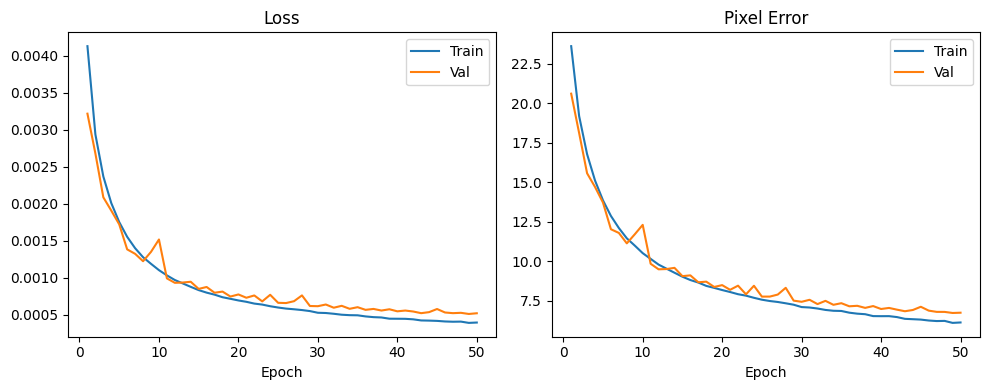

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
epochs = range(1, len(train_losses) + 1)

# Loss curves
ax[0].plot(epochs, train_losses, label="Train")
ax[0].plot(epochs, val_losses, label="Val")
ax[0].set_title("Loss")
ax[0].set_xlabel("Epoch")
ax[0].legend()

# Pixel error curves
ax[1].plot(epochs, train_errors, label="Train")
ax[1].plot(epochs, val_errors, label="Val")
ax[1].set_title("Pixel Error")
ax[1].set_xlabel("Epoch")
ax[1].legend()

plt.tight_layout()
plt.show()

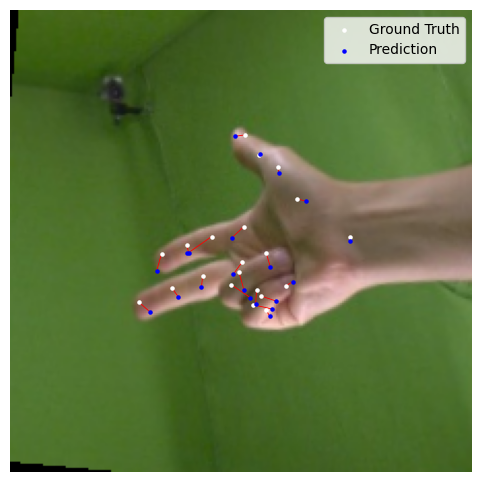

Mean error: 6.366077423095703
Max error: 14.314159393310547


In [16]:
# Get random sample
idx = random.randint(0, len(train_dataset) - 1)
sample = train_dataset[idx]
image = sample["image"].permute(1, 2, 0)
image = image * 0.5 + 0.5
image = image.clamp(0, 1)
uv_ground = sample["uv"] * 224

# Predict joints
model.eval()
with torch.no_grad():
    preds, heatmaps = model(sample["image"].unsqueeze(0).to(device))
    uv_pred = preds.squeeze(0).cpu() * 224

# Plot image
plt.figure(figsize=(6, 6))
plt.imshow(image)

# Ground truth joints
plt.scatter(uv_ground[:, 0], uv_ground[:, 1], c="w", s=5, label="Ground Truth", zorder=2)

# Predicted joints
plt.scatter(uv_pred[:, 0], uv_pred[:, 1], c="b", s=5, label="Prediction", zorder=2)

# Error lines
for ground, pred in zip(uv_ground, uv_pred):
    plt.plot([ground[0], pred[0]], [ground[1], pred[1]], "r", linewidth=0.6, zorder=1)

plt.axis("off")
plt.legend()
plt.show()

# Compute per-joint pixel error
errors = torch.norm(uv_pred - uv_ground, dim=-1)
print("Mean error:", errors.mean().item())
print("Max error:", errors.max().item())

In [17]:
# Export model
model.load_state_dict(torch.load("best_model_joint_mapping.pth", map_location=device))
model.eval()
torch.onnx.export(model, torch.randn(1, 3, 224, 224).to(device), "joint_mapping.onnx", input_names=["input"], output_names=["uv"], verbose=False)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/copyreg.py:105: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 20},
            producer_name='pytorch',
            producer_version='2.12.0',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"input"<FLOAT,[1,3,224,224]>
            ),
            outputs=(
                %"uv"<FLOAT,[1,21,2]>,
                %"conv2d_14"<FLOAT,[1,21,56,56]>
            ),
            initializers=(
                %"conv1.weight"<FLOAT,[64,3,7,7]>{Tensor(...)},
                %"layer1.main.0.weight"<FLOAT,[64,64,3,3]>{Tensor(...)},
                %"layer1.main.3.weight"<FLOAT,[64,64,3,3]>{Tensor(...)},
                %"layer1.shortcut.0.weight"<FLOAT,[64,64,1,1]>{Tensor(...)},
                %"layer2.main.0.weight"<FLOAT,[128,64,3,3]>{Tensor(...)},
                %"layer2.main.3.weight"<FLOAT,[128,128,3,3]>{Tensor(...)},
                %"layer2.shortcut.0.weight"<FL